In [1]:
import numpy
from Simulation.proposedmodels.synth_data import generate_nonlinear_snr
import matplotlib.pyplot as plt

In [2]:
views = generate_nonlinear_snr(100,100, 5, 25)


In [3]:
## HSIC-SGCCA
from solver_hsic import Solver
device = 'cpu'
solver = Solver(device=device)

u = solver.SNGCCA.fit_admm(views, constraint=[0.1,0.1,0.1], logging=0)

outer_iter=: 0,obj: 214.5, Loss: 6.24e-05, diff_list: [1.790e-05 1.250e-06 4.326e-05]:   0%|                                                                                     | 0/10 [00:03<?, ?it/s]


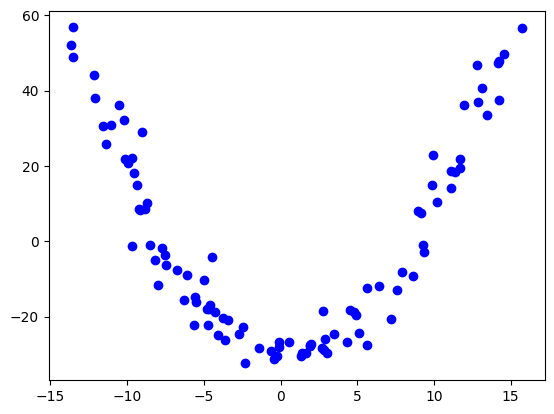

In [4]:
y = views[0] @ u[0]
z = views[1] @ u[1]
plt.plot(y, z, 'bo')
plt.show()

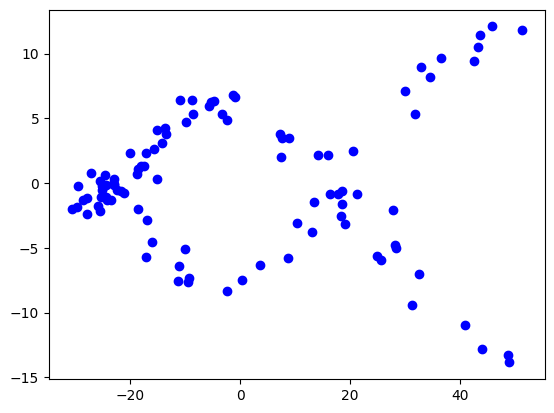

In [5]:
## TS-KGCCA
from Simulation.proposedmodels.ts_kgcca import tskgcca

s_k, u = tskgcca(views, stage = 1)
y = views[1] @ u[1]
z = views[2] @ u[2]
plt.plot(y, z, 'bo')
plt.show()

3
(100, 100)
(100, 100)
(100, 100)


D:\anaconda3\envs\NSGCCA\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


3
(100, 100)
(100, 100)
(100, 100)


D:\anaconda3\envs\NSGCCA\lib\site-packages\cvxpy\problems\problem.py:1539: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  warnings.warn(


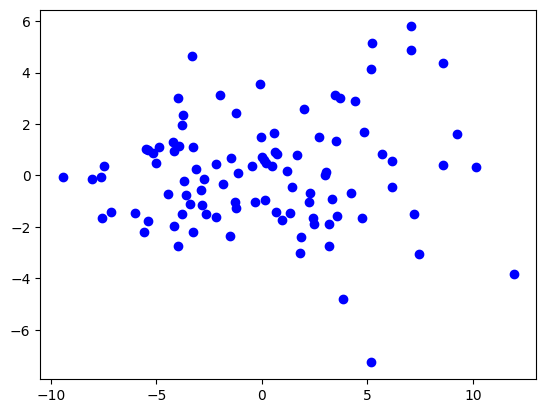

In [6]:
## SA-KGCCA
from Simulation.proposedmodels.sa_kgcca import sakgcca

# hyper parameter training
u1, u2, delta, best_alpha, best_s_k = sakgcca(views)
# training
u1, u2, delta, best_alpha, best_s_k = sakgcca(views, best_alpha=best_alpha, best_s_k=best_s_k)

y = views[1] @ u1[1]
z = views[2] @ u1[2]
plt.plot(y, z, 'bo')
plt.show()